In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


In [2]:
!nvidia-smi

Sat Jul 11 19:06:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
!unzip -q data.zip -d /content/data

In [11]:
%%writefile train_val_split.py

from pathlib import Path
import random
import os
import shutil
import argparse

parser = argparse.ArgumentParser()
parser.add_argument("--datapath", required=True)
parser.add_argument("--train_pct", type=float, default=0.8)

args = parser.parse_args()

data_path = args.datapath
train_percent = args.train_pct

if not os.path.isdir(data_path):
    raise FileNotFoundError(f"Dataset folder not found: {data_path}")

if not 0.01 <= train_percent <= 0.99:
    raise ValueError("train_pct must be between 0.01 and 0.99")

input_image_path = os.path.join(data_path, "images")
input_label_path = os.path.join(data_path, "labels")

train_img_path = os.path.join(data_path, "train", "images")
train_lbl_path = os.path.join(data_path, "train", "labels")

val_img_path = os.path.join(data_path, "validation", "images")
val_lbl_path = os.path.join(data_path, "validation", "labels")

for folder in [
    train_img_path,
    train_lbl_path,
    val_img_path,
    val_lbl_path,
]:
    os.makedirs(folder, exist_ok=True)

image_files = list(Path(input_image_path).glob("*"))

random.shuffle(image_files)

train_count = int(len(image_files) * train_percent)

train_files = image_files[:train_count]
val_files = image_files[train_count:]

def copy_dataset(files, image_dest, label_dest):
    for img_path in files:
        shutil.copy(img_path, image_dest)

        label_file = os.path.join(
            input_label_path,
            img_path.stem + ".txt"
        )

        if os.path.exists(label_file):
            shutil.copy(label_file, label_dest)

copy_dataset(train_files, train_img_path, train_lbl_path)
copy_dataset(val_files, val_img_path, val_lbl_path)

print("Dataset split completed successfully!")

Overwriting train_val_split.py


In [12]:
!python train_val_split.py --datapath="/content/data" --train_pct=0.9

Dataset split completed successfully!


In [13]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.0 MB/s eta 0:00:00


In [17]:
import yaml
import os

path_to_classes_txt = "/content/data/classes.txt"
path_to_data_yaml = "/content/data.yaml"

with open(path_to_classes_txt) as f:
    classes = [line.strip() for line in f if line.strip()]

data = {
    "path": "/content/data",
    "train": "train/images",
    "val": "validation/images",
    "nc": len(classes),
    "names": classes
}

with open(path_to_data_yaml, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Created:", path_to_data_yaml)
!cat /content/data.yaml

Created: /content/data.yaml
path: /content/data
train: train/images
val: validation/images
nc: 3
names:
- data
- legal
- photo


In [20]:
import os

train_dir = "/content/data/train/images"
val_dir = "/content/data/validation/images"

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

train_count = sum(
    1 for f in os.listdir(train_dir)
    if f.lower().endswith(image_exts)
)

val_count = sum(
    1 for f in os.listdir(val_dir)
    if f.lower().endswith(image_exts)
)

print(f"Training images   : {train_count}")
print(f"Validation images : {val_count}")
print(f"Total images      : {train_count + val_count}")

Training images   : 48
Validation images : 6
Total images      : 54


In [19]:
!yolo detect train \
    data=/content/data.yaml \
    model=yolo11s.pt \
    epochs=100 \
    imgsz=480

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [21]:
!yolo detect predict \
    model=/content/runs/detect/train/weights/best.pt \
    source=/content/data/validation/images \
    save=True

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

image 1/6 /content/data/validation/images/1f6ecec2-viber_image_2026-07-06_13-33-04-554_aug_0.jpg: 352x480 1 data, 1 legal, 1 photo, 58.3ms
image 2/6 /content/data/validation/images/450997ca-viber_image_2026-07-06_13-33-04-631_aug_2.jpg: 384x480 1 data, 1 legal, 1 photo, 55.4ms
image 3/6 /content/data/validation/images/4fc31c85-viber_image_2026-07-06_13-33-04-677_aug_4.jpg: 352x480 1 data, 1 legal, 1 photo, 13.0ms
image 4/6 /content/data/validation/images/aab4285e-viber_image_2026-07-06_13-33-05-328_aug_4.jpg: 384x480 1 data, 1 legal, 1 photo, 11.2ms
image 5/6 /content/data/validation/images/b4baaece-viber_image_2026-07-06_13-33-04-554_aug_3.jpg: 352x480 1 data, 1 legal, 1 photo, 11.1ms
image 6/6 /content/data/validation/images/b5f0a5e5-viber_image_2026-07-06_13-33-04-631_aug_4.jpg: 384x480 1 data, 1 legal, 1 photo, 13.1m

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


In [ ]:
# the citizenship data, in general is a sensitive data so i cleared the output of the previous cell 

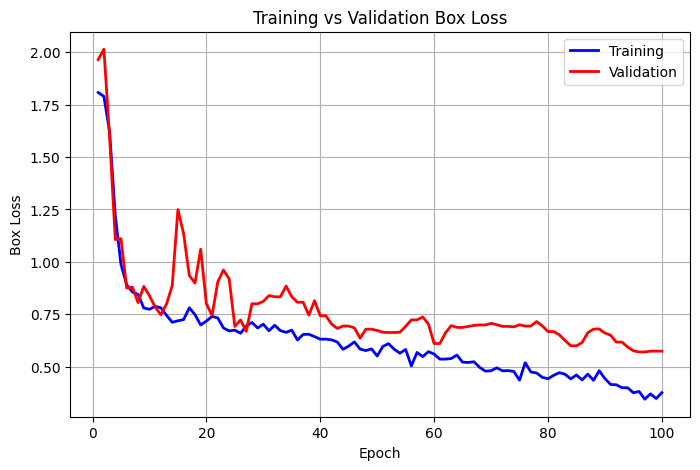

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/runs/detect/train/results.csv")

results.columns = results.columns.str.strip()

plt.figure(figsize=(8,5))

plt.plot(results["epoch"], results["train/box_loss"], "b-", linewidth=2, label="Training")
plt.plot(results["epoch"], results["val/box_loss"], "r-", linewidth=2, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Training vs Validation Box Loss")
plt.legend()
plt.grid(True)

plt.show()

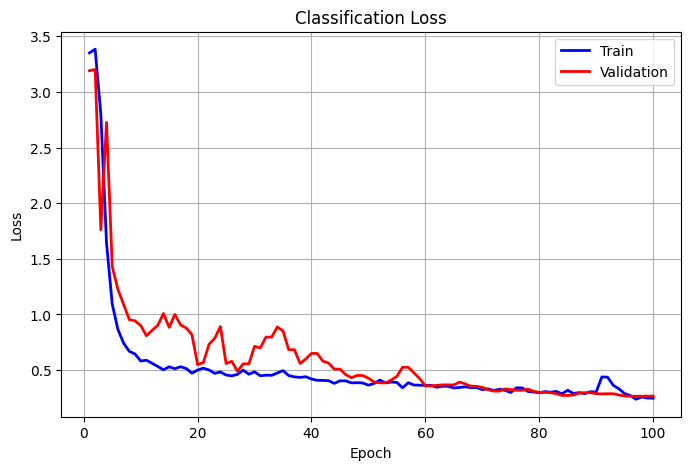

In [24]:
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/cls_loss"], "b-", linewidth=2, label="Train")
plt.plot(results["epoch"], results["val/cls_loss"], "r-", linewidth=2, label="Validation")
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

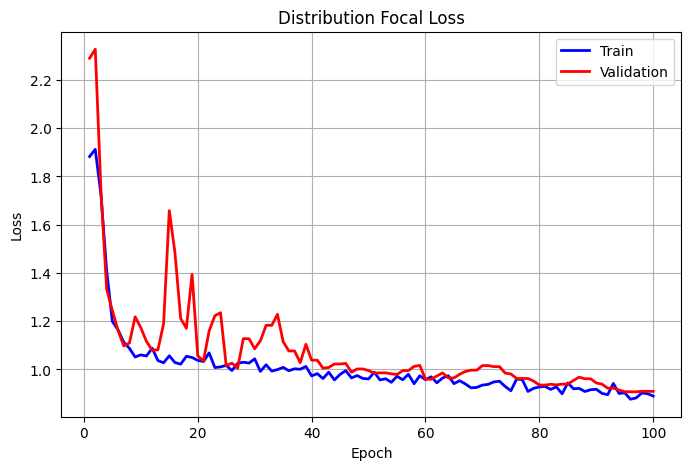

In [25]:
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/dfl_loss"], "b-", linewidth=2, label="Train")
plt.plot(results["epoch"], results["val/dfl_loss"], "r-", linewidth=2, label="Validation")
plt.title("Distribution Focal Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

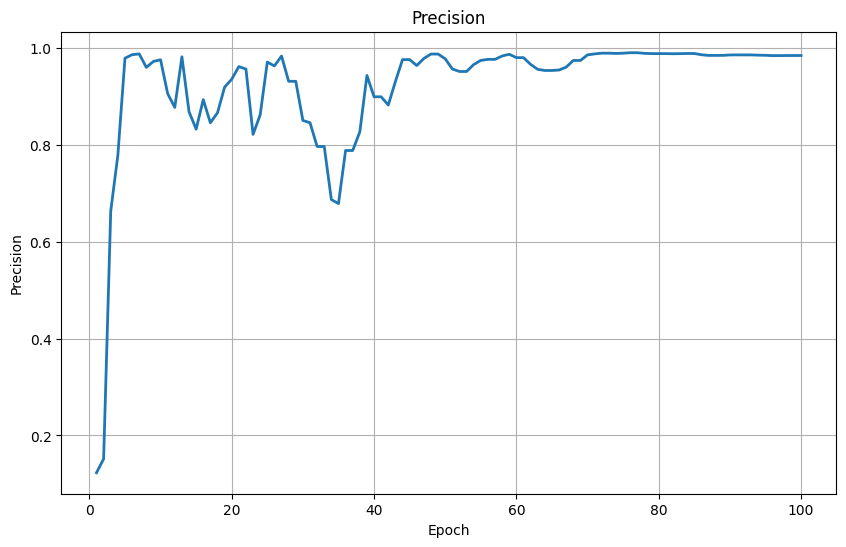

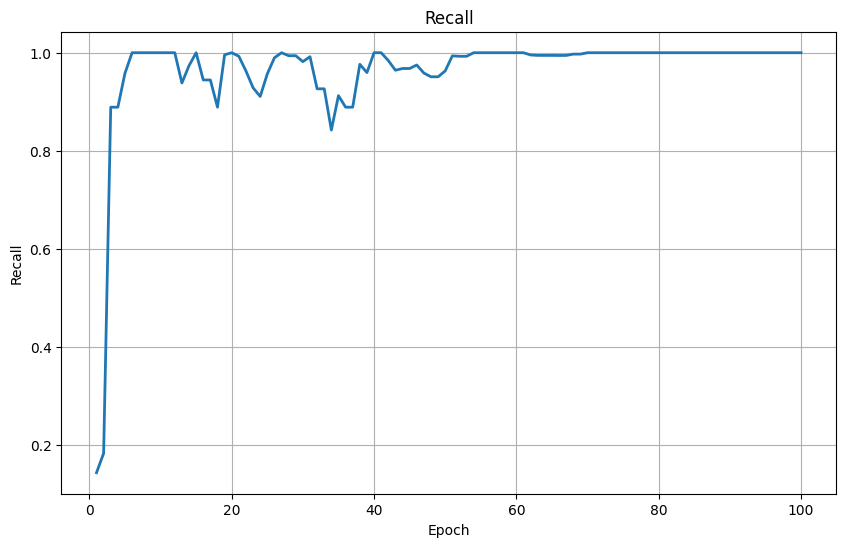

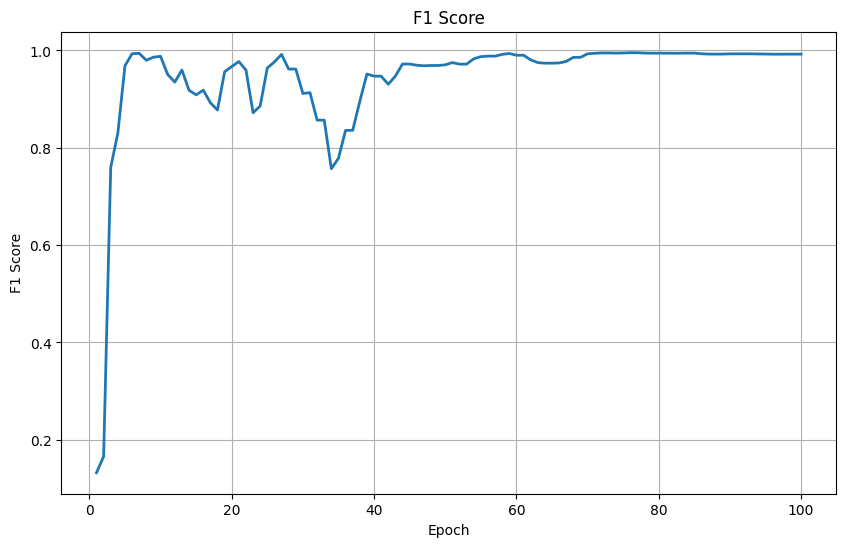

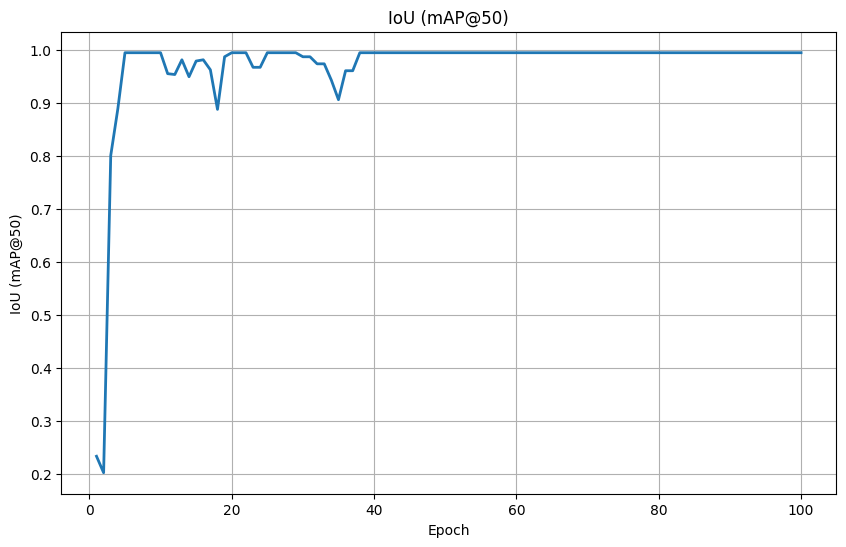


Final Metrics:
Precision : 0.9848
Recall    : 1.0000
F1 Score  : 0.9923
IoU(mAP50): 0.9950
mAP50-95  : 0.8674


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# CHANGE THIS PATH if your results.csv is elsewhere
results_csv = "/content/runs/detect/train/results.csv"

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
iou = df["metrics/mAP50(B)"]
f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

metrics = [
    ("Precision", precision),
    ("Recall", recall),
    ("F1 Score", f1),
    ("IoU (mAP@50)", iou),
]

for title, values in metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(df["epoch"], values, linewidth=2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.grid(True)
    plt.show()

print("\nFinal Metrics:")
print(f"Precision : {precision.iloc[-1]:.4f}")
print(f"Recall    : {recall.iloc[-1]:.4f}")
print(f"F1 Score  : {f1.iloc[-1]:.4f}")
print(f"IoU(mAP50): {iou.iloc[-1]:.4f}")
print(f"mAP50-95  : {df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")